--- Đang tải dữ liệu ---

--- 5 Dòng đầu tiên của dữ liệu ---
           event_time event_type  product_id          category_id  \
0 2019-11-01 00:00:00       view     1003461  2053013555631882655   
1 2019-11-01 00:00:00       view     5000088  2053013566100866035   
2 2019-11-01 00:00:01       view    17302664  2053013553853497655   
3 2019-11-01 00:00:01       view     3601530  2053013563810775923   
4 2019-11-01 00:00:01       view     1004775  2053013555631882655   

               category_code   brand   price    user_id  \
0     electronics.smartphone  xiaomi  489.07  520088904   
1  appliances.sewing_machine  janome  293.65  530496790   
2                        NaN   creed   28.31  561587266   
3  appliances.kitchen.washer      lg  712.87  518085591   
4     electronics.smartphone  xiaomi  183.27  558856683   

                           user_session  
0  4d3b30da-a5e4-49df-b1a8-ba5943f1dd33  
1  8e5f4f83-366c-4f70-860e-ca7417414283  
2  755422e7-9040-477b-9bd2-6a6e8fd97387  


C:\Users\ACER\AppData\Local\Temp\ipykernel_4040\1049170906.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=event_counts.index, y=event_counts.values, palette="Blues_d")


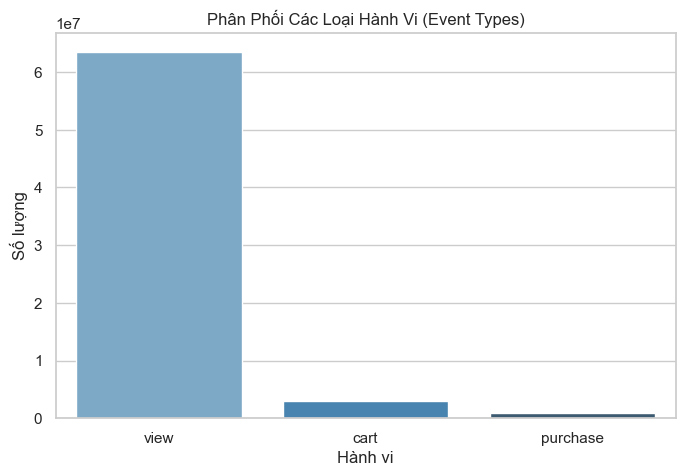


Tỷ lệ chuyển đổi tổng thể (Purchase / Total Events): 1.36%

--- Thống kê về giá sản phẩm (Price) ---
count    6.750198e+07
mean     2.924593e+02
std      3.556745e+02
min      0.000000e+00
25%      6.924000e+01
50%      1.657700e+02
75%      3.603400e+02
max      2.574070e+03
Name: price, dtype: float64


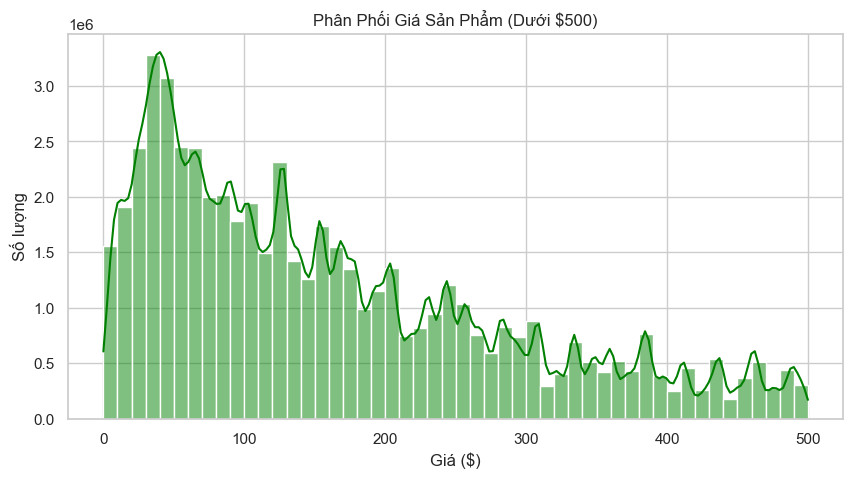


--- Top 10 Thương hiệu doanh thu cao nhất ---


C:\Users\ACER\AppData\Local\Temp\ipykernel_4040\1049170906.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands_revenue.values, y=top_brands_revenue.index, palette="rocket")


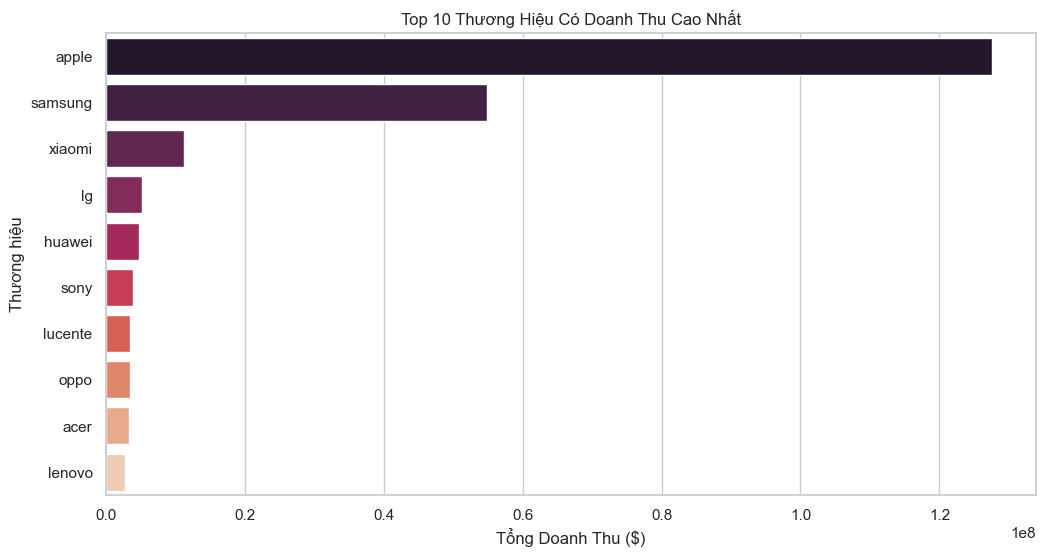

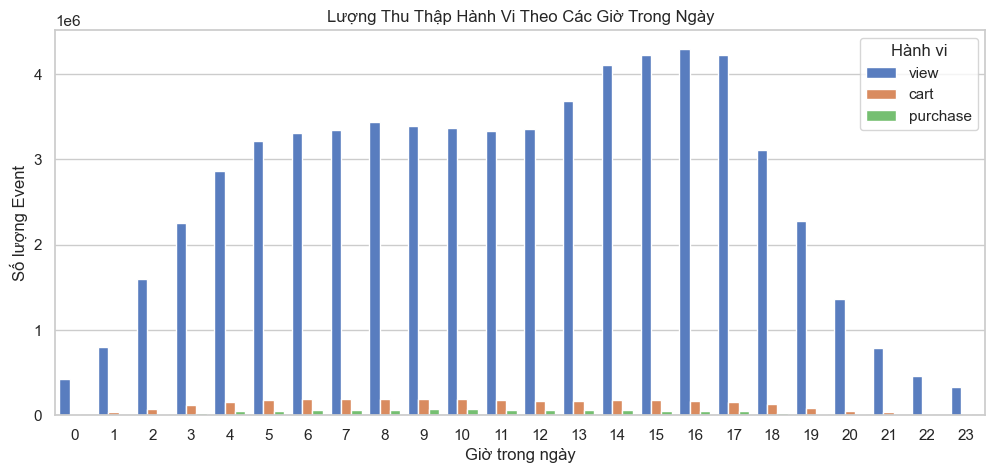

C:\Users\ACER\AppData\Local\Temp\ipykernel_4040\1049170906.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['event_type'] == 'purchase'], x='day_of_week', order=order_days, palette="pastel")


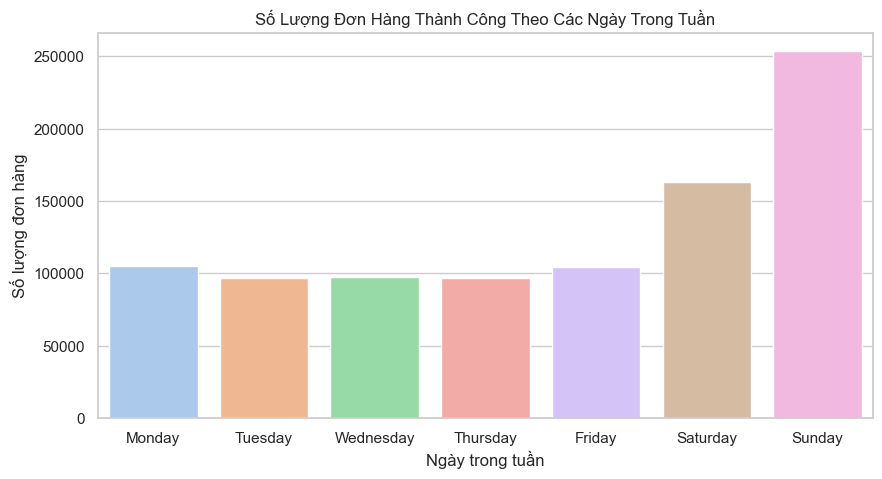

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# 1. ĐỌC DỮ LIỆU (Tối ưu hóa cho file lớn)
# ==========================================
FILE_PATH = r"E:\Datamining\2019-Nov.csv"  # Thay đổi đường dẫn đến file của bạn

print("--- Đang tải dữ liệu ---")
# Đọc sample 1,000,000 dòng để phân tích nhanh, hoặc bỏ nrows nếu máy mạnh
df = pd.read_csv(FILE_PATH) 

# Chuyển đổi định dạng thời gian
df['event_time'] = pd.to_datetime(df['event_time'].str.replace(' UTC', ''), format='%Y-%m-%d %H:%M:%S')

# ==========================================
# 2. TỔNG QUAN DỮ LIỆU
# ==========================================
print("\n--- 5 Dòng đầu tiên của dữ liệu ---")
print(df.head())

print("\n--- Thông tin cấu trúc dữ liệu ---")
print(df.info())

print("\n--- Kiểm tra giá trị thiếu (Missing Values) ---")
print(df.isnull().sum())

print("\n--- Thống kê số lượng Unique Values ---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} giá trị duy nhất")

# ==========================================
# 3. PHÂN TÍCH HÀNH VI KHÁCH HÀNG (event_type)
# ==========================================
print("\n--- Tỷ lệ các loại hành vi (view, cart, purchase) ---")
event_counts = df['event_type'].value_counts()
print(event_counts)

# Vẽ biểu đồ hành vi
plt.figure(figsize=(8, 5))
sns.barplot(x=event_counts.index, y=event_counts.values, palette="Blues_d")
plt.title("Phân Phối Các Loại Hành Vi (Event Types)")
plt.ylabel("Số lượng")
plt.xlabel("Hành vi")
plt.show()

# Tỷ lệ chuyển đổi (Conversion Rate)
total_events = len(df)
purchase_count = df[df['event_type'] == 'purchase'].shape[0]
conversion_rate = (purchase_count / total_events) * 100
print(f"\nTỷ lệ chuyển đổi tổng thể (Purchase / Total Events): {conversion_rate:.2f}%")

# ==========================================
# 4. PHÂN TÍCH DOANH THU & GIÁ CẢ
# ==========================================
print("\n--- Thống kê về giá sản phẩm (Price) ---")
print(df['price'].describe())

# Phân bố giá sản phẩm (Bỏ qua các sản phẩm quá đắt làm nhiễu biểu đồ)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] < 500]['price'], bins=50, kde=True, color='green')
plt.title("Phân Phối Giá Sản Phẩm (Dưới $500)")
plt.xlabel("Giá ($)")
plt.ylabel("Số lượng")
plt.show()

# Top 10 Thương hiệu có doanh thu cao nhất (chỉ tính 'purchase')
print("\n--- Top 10 Thương hiệu doanh thu cao nhất ---")
purchases = df[df['event_type'] == 'purchase']
top_brands_revenue = purchases.groupby('brand')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_brands_revenue.values, y=top_brands_revenue.index, palette="rocket")
plt.title("Top 10 Thương Hiệu Có Doanh Thu Cao Nhất")
plt.xlabel("Tổng Doanh Thu ($)")
plt.ylabel("Thương hiệu")
plt.show()

# ==========================================
# 5. PHÂN TÍCH THEO THỜI GIAN (Time Series)
# ==========================================
# Tách thêm cột giờ và thứ trong tuần
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()

# Hành vi theo các giờ trong ngày
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='hour', hue='event_type', palette="muted")
plt.title("Lượng Thu Thập Hành Vi Theo Các Giờ Trong Ngày")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Số lượng Event")
plt.legend(title="Hành vi")
plt.show()

# Mua sắm theo các ngày trong tuần
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['event_type'] == 'purchase'], x='day_of_week', order=order_days, palette="pastel")
plt.title("Số Lượng Đơn Hàng Thành Công Theo Các Ngày Trong Tuần")
plt.xlabel("Ngày trong tuần")
plt.ylabel("Số lượng đơn hàng")
plt.show()

In [2]:
import json

# Gom toàn bộ tri thức, số liệu đã trích xuất ở các bước trên vào 1 cấu trúc chuẩn
eda_output_data = {
    "total_events": int(total_events),
    "conversion_rate": round(conversion_rate, 2),
    "event_distribution": event_counts.to_dict(),
    "price_descriptive_stats": df['price'].describe().to_dict(),
    # Nếu bạn có tính toán thêm dữ liệu theo giờ hoặc theo thứ thì gom vào đây, ví dụ:
    # "hourly_data": df.groupby('hour')['event_type'].value_counts().unstack().fillna(0).to_dict(orient='records')
}

# Tiến hành đóng gói và ghi thành file JSON
with open('eda_results.json', 'w', encoding='utf-8') as f:
    json.dump(eda_output_data, f, ensure_ascii=False, indent=2)

print("=== ĐỒNG BỘ HOÀN TẤT ===")
print("-> Đã xuất toàn bộ kết quả phân tích EDA ra file: eda_results.json")

=== ĐỒNG BỘ HOÀN TẤT ===
-> Đã xuất toàn bộ kết quả phân tích EDA ra file: eda_results.json
